# **IMPORT LIBRARIES**

In [1]:
# import libraries

import pandas as pd
import re
import string
import csv
import requests
from io import StringIO
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# **LOAD DATASET**

In [3]:
# membaca dan mulai preproses dataset

df = pd.read_csv("./youtube_comments.csv")
print(df.head())
print(df.info())

clean_df = df.dropna(subset=["Comment"])
clean_df = df.drop_duplicates()
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = (
    clean_df.shape
)
clean_df.info()

                                             Comment  Likes
0  i miss all of this moment, i watched this when...      0
1             'I love how you started off saying you      0
2                   how has it been been 6 years?! 🥲      1
3                                  We are back boys.      1
4                                    i miss this shi      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123888 entries, 0 to 123887
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Comment  123887 non-null  object
 1   Likes    123888 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 115544 entries, 0 to 123887
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Comment  115543 non-null  object
 1   Likes    115544 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.6+ MB


# **PRE-PROCESS TEXT**

In [5]:
# preproses teks untuk dataset

nltk.download("stopwords")
nltk.download('punkt_tab')

def cleaningText(text):
    text = str(text)
    text = re.sub(r"@[A-Za-z0-9]+", "", text)
    text = re.sub(r"#[A-Za-z0-9]+", "", text)
    text = re.sub(r"RT[\s]", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[0-9]+", "", text)
    text = re.sub(r"[^\w\s]", "", text)

    text = text.replace("\n", " ")
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = text.strip(" ")
    return text


def casefoldingText(text):
    text = text.lower()
    return text


def tokenizingText(text):
    text = word_tokenize(text)
    return text


def filteringText(text):
    stop_words = set(stopwords.words("english"))
    negation_words = {"not", "no", "never", "neither", "nor", "but", "none"}
    final_stop_words = stop_words - negation_words
    youtube_noise = {"br", "href"}
    final_stop_words.update(youtube_noise)
    filtered = []
    for txt in text:
        if txt not in final_stop_words:
            filtered.append(txt)
    text = filtered
    return text


def toSentence(list_words):  # Mengubah daftar kata menjadi kalimat
    sentence = " ".join(word for word in list_words)
    return sentence


clean_df["text_clean"] = clean_df["Comment"].apply(cleaningText)
clean_df["text_casefoldingText"] = clean_df["text_clean"].apply(casefoldingText)
clean_df["text_tokenizingText"] = clean_df["text_casefoldingText"].apply(tokenizingText)
clean_df["text_stopword"] = clean_df["text_tokenizingText"].apply(filteringText)
clean_df["text_akhir"] = clean_df["text_stopword"].apply(toSentence)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/tmp/ipykernel_6955/475363383.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["text_clean"] = clean_df["Comment"].apply(cleaningText)
/tmp/ipykernel_6955/475363383.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["text_casefoldingText"] = clean_df["tex

# **LABELING**

In [6]:
# labeling

nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()


def get_vader_label(text):
    score = sia.polarity_scores(text)
    if score["compound"] >= 0:
        polarity = "positive"
    else:
        polarity = "negative"

    return score["compound"], polarity


result = clean_df["text_akhir"].apply(get_vader_label)
result = list(zip(*result))

clean_df["polarity_score"] = result[0]
clean_df["polarity"] = result[1]

print(clean_df["polarity"].value_counts())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


polarity
positive    95549
negative    19995
Name: count, dtype: int64


/tmp/ipykernel_6955/3919171299.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["polarity_score"] = result[0]
/tmp/ipykernel_6955/3919171299.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["polarity"] = result[1]


# **VISUALISASI WORDCLOUD**

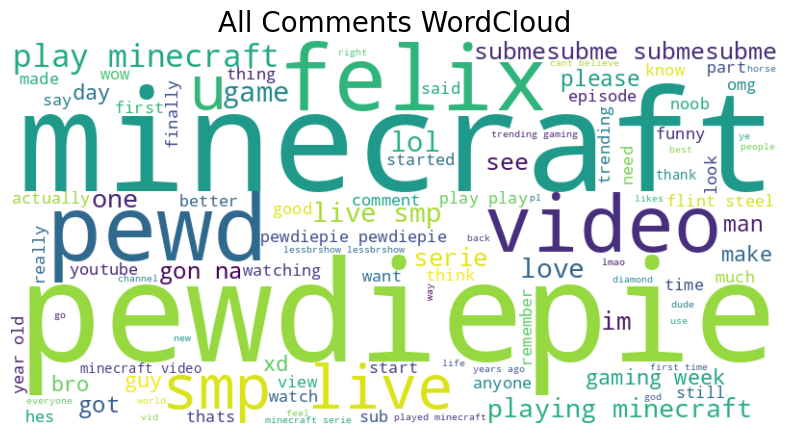

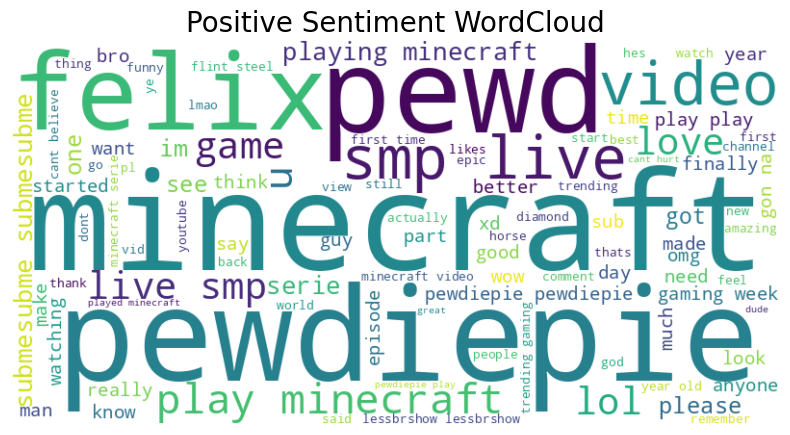

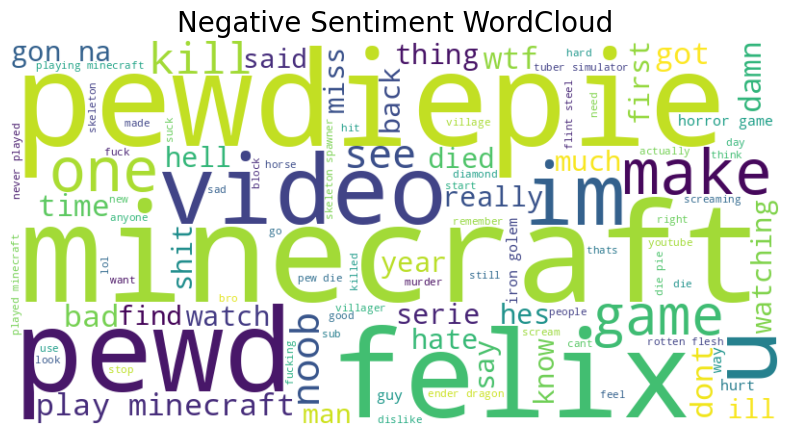

In [8]:
# visualisasi dengan wordcloud

def show_wordcloud(data, title):
    text = " ".join(review for review in data)
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100,
        colormap="viridis",
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(title, fontsize=20)
    plt.axis("off")
    plt.show()


show_wordcloud(clean_df["text_akhir"], "All Comments WordCloud")
print()
pos_data = clean_df[clean_df["polarity"] == "positive"]["text_akhir"]
show_wordcloud(pos_data, "Positive Sentiment WordCloud")
print()
neg_data = clean_df[clean_df["polarity"] == "negative"]["text_akhir"]
show_wordcloud(neg_data, "Negative Sentiment WordCloud")

# **FEATURE EXTRACTION**

In [9]:
# TF-IDF Feature Extraction

X = clean_df["text_akhir"]
y = clean_df["polarity"]

tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8)
X_tfidf = tfidf.fit_transform(X)

features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

features_df

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# **TRAIN & TEST MODEL RF**

In [10]:
# train dan test model Random Forest

random_forest = RandomForestClassifier()

random_forest.fit(X_train.toarray(), y_train)

y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

print("Random Forest - accuracy_train:", accuracy_train_rf)
print("Random Forest - accuracy_test:", accuracy_test_rf)

Random Forest - accuracy_train: 0.9305025152810082
Random Forest - accuracy_test: 0.8651607598771042


# **INSIGHT**

Sentiment analysis ini menggunakan dataset yang diambil dari komentar youtube kanal 'pewdiepie' dari videonya yang berjudul 'MINECRAFT PART 1'. Total komentar berada di angka 151,649 komentar dan diambil +- 100,000 untuk dataset ini.

Analisis ini menggunakan teknik Ekstraksi Fitur (TF-IDF), model algoritma Random Forest. Setelah melakukan perbandingan hasil training dan test pada 4 model yang disediakan dalam modul pembelajaran, model Random Forest diambil karena menghasilkan persenan yang paling tinggi yaitu training 93% dan test 86%. Hasil tersebut mengindikasikan bahwa model sudah baik dalam mengenali pola sentimen tanpa overfitting yang signifikan.